# 4. Model Evaluation

This notebook focuses on evaluating the performance of a trained geo-spatial model. It loads true and predicted classes on the test set, computes relevant performance metrics, and visualizes the results to assess model accuracy and generalization. Amongst other metrics, it calculates overall accuracy, balanced accuracy, per-class performance and plots confusion matrices. These are compared between different normalization functions.

Expected input format for the data: .npz file in the directory `EVAL_ROOT` with the name `evaluation_outputs.npz`. The file should contain true and predicted classes on the test set, as well as the class names. This format fits with the file saved at the end of the `3_training_pipeline.ipynb` notebook. 

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (confusion_matrix, classification_report)

print("✓ Imports successful")

✓ Imports successful


In [2]:
%matplotlib inline

In [48]:
import os
SCRATCH = os.getenv("SCRATCH")

NORMALIZATION_TYPES = {
    "none": "normalization_none",
    "minmax": "normalization_minmax",
    "percentile": "normalization_percentile",
    "zscore": "normalization_zscore",
}

EVAL_ROOT = Path(f"{SCRATCH}/team1/data/evaluation/")

# Output path
RESULTS_DIR = Path(os.environ["PROJECT_training2600"]) / "team1" / "evaluation_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

### Import Evaluation Data (test predictions)

In [12]:
# Importing the evaluation data for all normalization types
results = {}

for name, folder in NORMALIZATION_TYPES.items():
    eval_path = EVAL_ROOT / folder / "evaluation_outputs.npz"
    data = np.load(eval_path, allow_pickle=True)
    
    results[name] = {
        "y_true": data["y_true"],
        "y_pred": data["y_pred"],
        "class_names": data["class_names"].tolist(),
    }

    print(f"Loaded {name}: {len(data['y_true'])} samples")

Loaded none: 9997 samples
Loaded minmax: 9997 samples
Loaded percentile: 9997 samples
Loaded zscore: 9997 samples


In [13]:
# Sanity check to ensure that the models have the same "y_true" and "class_names"
first_name = list(results.keys())[0]
reference_y_true = results[first_name]["y_true"]
reference_class_names = results[first_name]["class_names"]

for name, result in results.items():
    assert np.array_equal(result["y_true"], reference_y_true), f"y_true differs for {name}"
    assert result["class_names"] == reference_class_names, f"class_names differ for {name}"

print("All runs use the same y_true and class names.")

All runs use the same y_true and class names.


In [14]:
# Print ground truth and prediction distributions per normalization type
for norm_type, result in results.items():
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    class_names = result["class_names"]
    n_classes = len(class_names)

    print("=" * 80)
    print(f"Normalization type: {norm_type}")
    print(f"Test set: {len(y_true)} samples, {n_classes} classes")
    print(f"Ground truth distribution: {np.bincount(y_true, minlength=n_classes)}")
    print(f"Prediction distribution:  {np.bincount(y_pred, minlength=n_classes)}")
    print(class_names)
    print()

Normalization type: none
Test set: 9997 samples, 8 classes
Ground truth distribution: [ 166 6860  193  494  768  275  783  458]
Prediction distribution:  [   0    0    0    0 9004   32  954    7]
['agriculture_with_natural_vegetation', 'coniferous_forest', 'discontinuous_urban_fabric', 'mixed_forest', 'non_irrigated_arable_land', 'peat_bogs', 'transitional_woodland_shrub', 'water_bodies']

Normalization type: minmax
Test set: 9997 samples, 8 classes
Ground truth distribution: [ 166 6860  193  494  768  275  783  458]
Prediction distribution:  [   0    0    0    0 9748  123  110   16]
['agriculture_with_natural_vegetation', 'coniferous_forest', 'discontinuous_urban_fabric', 'mixed_forest', 'non_irrigated_arable_land', 'peat_bogs', 'transitional_woodland_shrub', 'water_bodies']

Normalization type: percentile
Test set: 9997 samples, 8 classes
Ground truth distribution: [ 166 6860  193  494  768  275  783  458]
Prediction distribution:  [   2    0 1847    3 7688  318    0  139]
['agricult

### Evaluation Functions

- Overall Accuracy: % of all correct predictions
- Balanced Accuracy: Mean recall per class
- Macro-F1: Mean F1 per class

In [17]:
def _confusion_matrix(y_true, y_pred):
    """Build confusion matrix handling arbitrary class labels."""
    labels = np.unique(np.concatenate([y_true, y_pred]))
    label_to_idx = {int(lbl): i for i, lbl in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[int(t)], label_to_idx[int(p)]] += 1
    return labels, cm

In [18]:
def _imbalanced_metrics_from_cm(cm):
    """Compute balanced accuracy, macro-F1, and per-class metrics from confusion matrix."""
    tp = np.diag(cm).astype(np.float64)
    support = cm.sum(axis=1).astype(np.float64)
    pred_count = cm.sum(axis=0).astype(np.float64)

    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    precision = np.divide(tp, pred_count, out=np.zeros_like(tp), where=pred_count > 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp),
        where=(precision + recall) > 0,
    )

    balanced_acc = recall.mean()
    macro_f1 = f1.mean()
    overall_acc = tp.sum() / cm.sum() if cm.sum() > 0 else 0.0
    return overall_acc, balanced_acc, macro_f1, recall, precision, f1

### Compute Overall Metrics

In [51]:
# Prints a table with overall accuracy, balanced accuracy and macro F1 score
summary_rows = []

for name, result in results.items():
    y_true = result["y_true"]
    y_pred = result["y_pred"]

    labels, cm = _confusion_matrix(y_true, y_pred)
    overall_acc, balanced_acc, macro_f1, recall, precision, f1 = _imbalanced_metrics_from_cm(cm)

    summary_rows.append({
        "Normalization": name,
        "Overall accuracy": overall_acc,
        "Balanced accuracy": balanced_acc,
        "Macro-F1": macro_f1,
        "Gap (Acc - Bal Acc)": overall_acc - balanced_acc,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RESULTS_DIR / "summary_metrics.csv", index=False) # Saving .csv file

summary_df

,Normalization,Overall accuracy,Balanced accuracy,Macro-F1,Gap (Acc - Bal Acc)
0,none,0.083425,0.136285,0.036046,-0.052860
1,minmax,0.078323,0.129226,0.027640,-0.050902
2,percentile,0.081725,0.157572,0.071279,-0.075848
3,zscore,0.094328,0.176506,0.064624,-0.082178


In [52]:
# Majority baseline comparison for each normalization type

baseline_rows = []

for name, result in results.items():
    y_true = result["y_true"]

    vals, cnts = np.unique(y_true, return_counts=True)
    majority_class = vals[np.argmax(cnts)] # Index of majority class
    majority_baseline = cnts.max() / len(y_true) # Accuracy of a naive majority classifier

    # Get model accuracy from the existing summary table
    balanced_acc = summary_df.loc[
        summary_df["Normalization"] == name,
        "Balanced accuracy"
    ].iloc[0]

    baseline_rows.append({
        "Normalization": name,
        "Majority class": majority_class,
        "Majority baseline": majority_baseline,
        "Balanced accuracy": balanced_acc,
        "Improvement over majority baseline": balanced_acc - majority_baseline,
    })

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(RESULTS_DIR / "majority_baseline_comparison.csv", index=False) # Saving .csv file
baseline_df

,Normalization,Majority class,Majority baseline,Balanced accuracy,Improvement over majority baseline
0,none,1,0.686206,0.136285,-0.549920
1,minmax,1,0.686206,0.129226,-0.556980
2,percentile,1,0.686206,0.157572,-0.528634
3,zscore,1,0.686206,0.176506,-0.509700


### Per-Class Metrics

In [53]:
# Per-class precision, recall, f1-score and support for each normalization type
# Explanation: Support is the number of actual occurrences of the class in the dataset
for norm_type, result in results.items():
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    class_names = result["class_names"]

    class_names_with_idx = [
        f"{i}: {name}" for i, name in enumerate(class_names)
    ]

    print("=" * 100)
    print(f"Classification report - {norm_type}")
    print("=" * 100)

    report = classification_report(
        y_true,
        y_pred,
        labels=range(len(class_names)),
        target_names=class_names_with_idx,
        digits=4,
        zero_division=0,
    )

    print(report)
    print()

    # Saving .csv file for each normalization type
    report_df = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=range(len(class_names)),
            target_names=class_names_with_idx,
            digits=4,
            zero_division=0,
            output_dict=True,
        )
    ).T
    report_df.to_csv(RESULTS_DIR / f"per_class_{norm_type}.csv")
print(f"Saved CSV files to: {RESULTS_DIR}")

Classification report - none
                                        precision    recall  f1-score   support

0: agriculture_with_natural_vegetation     0.0000    0.0000    0.0000       166
                  1: coniferous_forest     0.0000    0.0000    0.0000      6860
         2: discontinuous_urban_fabric     0.0000    0.0000    0.0000       193
                       3: mixed_forest     0.0000    0.0000    0.0000       494
          4: non_irrigated_arable_land     0.0813    0.9531    0.1498       768
                          5: peat_bogs     0.0312    0.0036    0.0065       275
        6: transitional_woodland_shrub     0.1006    0.1226    0.1105       783
                       7: water_bodies     0.7143    0.0109    0.0215       458

                              accuracy                         0.0834      9997
                             macro avg     0.1159    0.1363    0.0360      9997
                          weighted avg     0.0477    0.0834    0.0213      9997


Classif

### Confusion matrices

none :


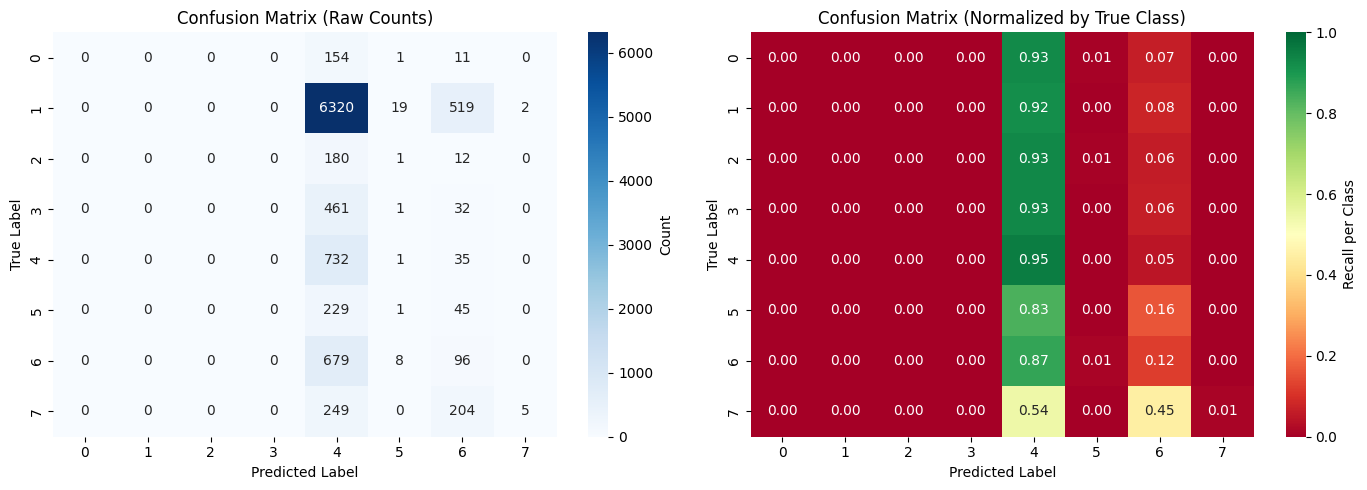

minmax :


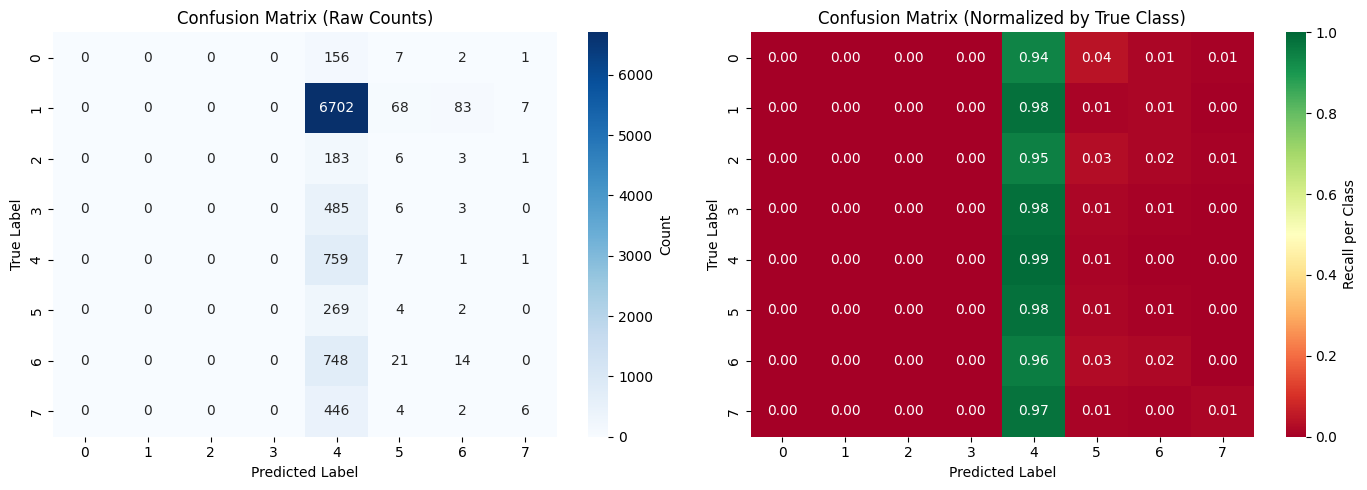

percentile :


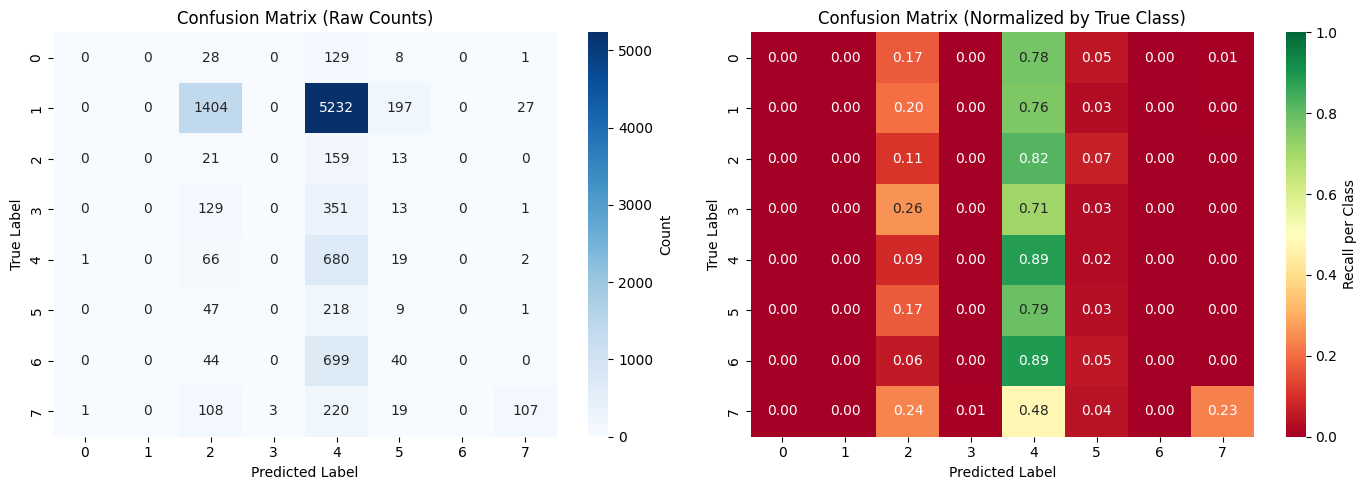

zscore :


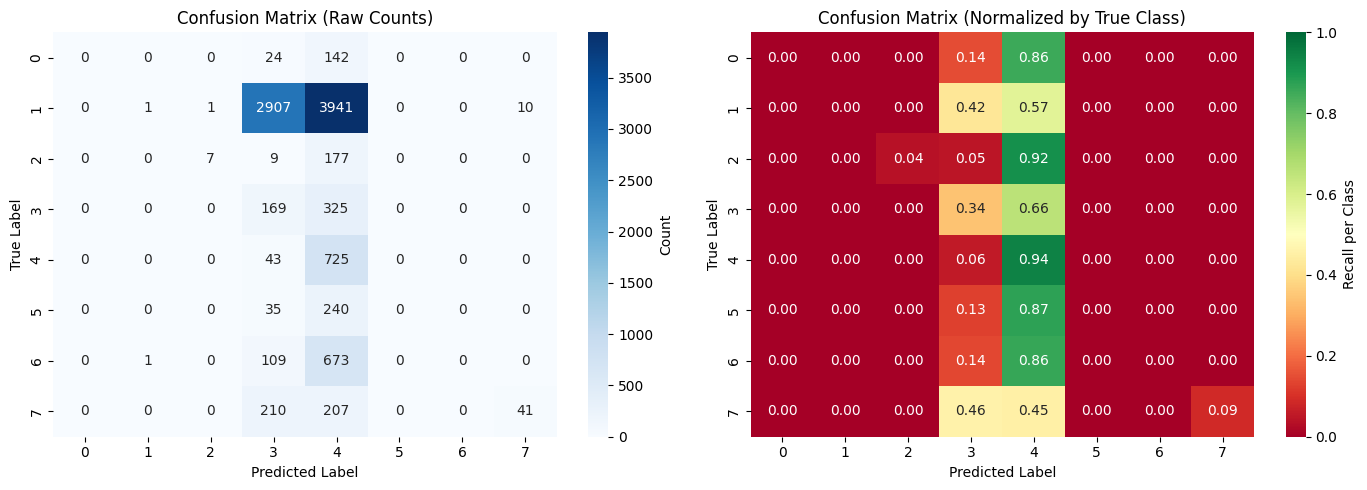

Diagonal = correct predictions per class
Dark values in confusion matrix indicate accurate predictions


In [58]:
# Displaying confusion matricies (both with raw counts and normalized by true class)
for norm_type, result in results.items():

    print(norm_type,":")

    y_true = result["y_true"]
    y_pred = result["y_pred"]
    class_names = result["class_names"]
    n_classes = len(class_names)
    
    cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'},
                xticklabels=range(n_classes), yticklabels=range(n_classes),
                ax=axes[0])
    axes[0].set_title('Confusion Matrix (Raw Counts)')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                cbar_kws={'label': 'Recall per Class'},
                xticklabels=range(n_classes), yticklabels=range(n_classes),
                ax=axes[1])
    axes[1].set_title('Confusion Matrix (Normalized by True Class)')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()

print("Diagonal = correct predictions per class")
print("Dark values in confusion matrix indicate accurate predictions")

In [60]:
# Saving confusion matricies normalized by true class
for norm_type, result in results.items():

    y_true = result["y_true"]
    y_pred = result["y_pred"]
    class_names = result["class_names"]
    n_classes = len(class_names)
    
    cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(7, 5))
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                cbar_kws={'label': 'Recall per Class'},
                xticklabels=range(n_classes), yticklabels=range(n_classes),
                ax=ax)
    ax.set_title('Confusion Matrix (Normalized by True Class)')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    
    plt.tight_layout()

    plt.tight_layout()
    fig.savefig(
        RESULTS_DIR / f"confusion_matrix_normalized_{norm_type}.png",
        dpi=600,
        bbox_inches="tight"
    )
    
    plt.close(fig)

### Class Distribution Analysis

none :


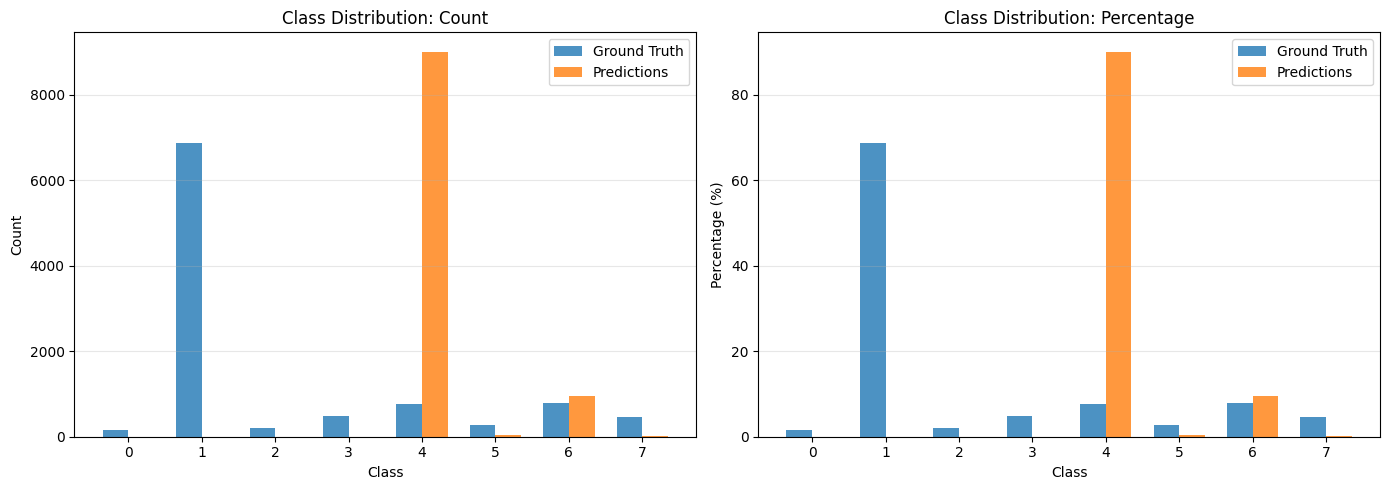

minmax :


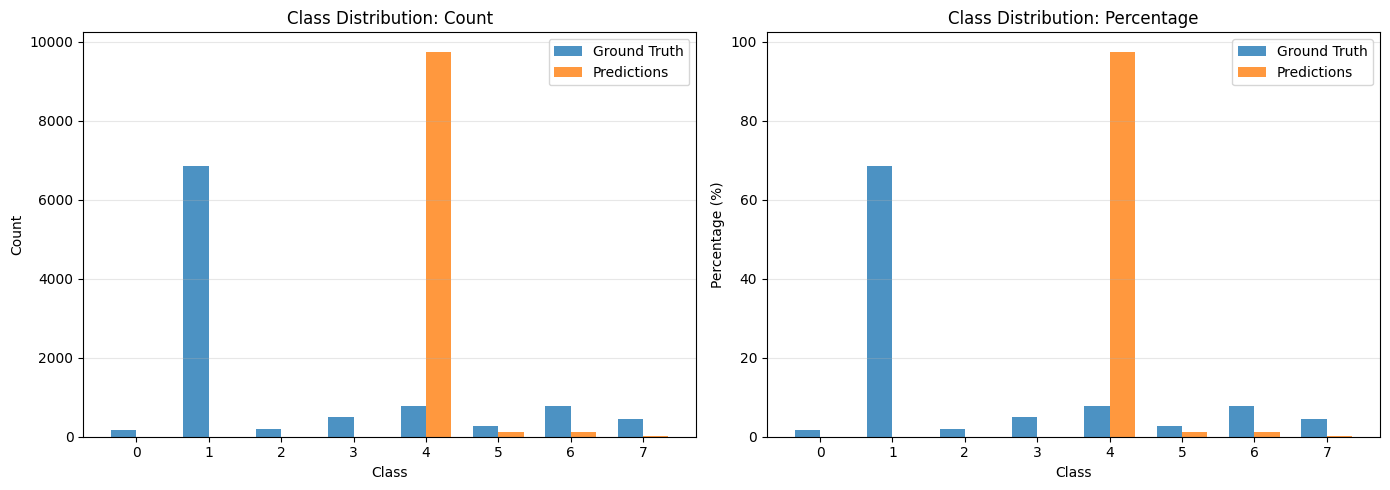

percentile :


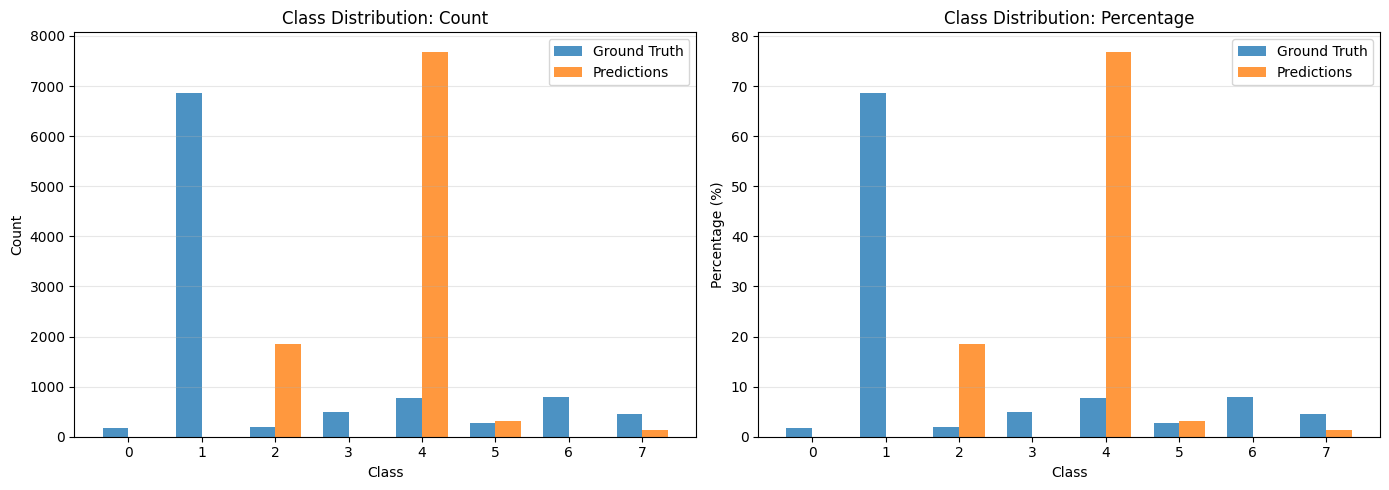

zscore :


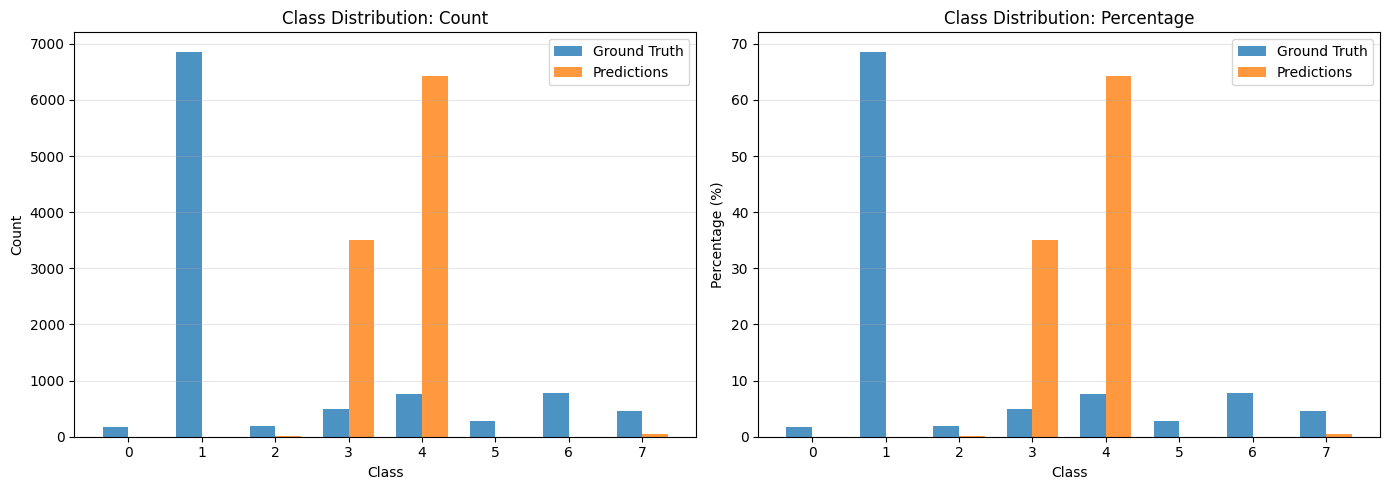

In [61]:
for norm_type, result in results.items():

    y_true = result["y_true"]
    y_pred = result["y_pred"]
    class_names = result["class_names"]
    n_classes = len(class_names)

    print(norm_type, ":")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    true_dist = pd.Series(y_true).value_counts().sort_index()
    pred_dist = pd.Series(y_pred).value_counts().sort_index()
    
    for i in range(n_classes):
        if i not in true_dist.index:
            true_dist[i] = 0
        if i not in pred_dist.index:
            pred_dist[i] = 0
    
    true_dist = true_dist.sort_index()
    pred_dist = pred_dist.sort_index()
    
    # Count plot
    x_pos = np.arange(n_classes)
    width = 0.35
    axes[0].bar(x_pos - width/2, true_dist.values, width, label='Ground Truth', alpha=0.8)
    axes[0].bar(x_pos + width/2, pred_dist.values, width, label='Predictions', alpha=0.8)
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Class Distribution: Count')
    axes[0].set_xticks(x_pos)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Percentage plot
    true_pct = 100 * true_dist / true_dist.sum()
    pred_pct = 100 * pred_dist / pred_dist.sum()
    
    axes[1].bar(x_pos - width/2, true_pct.values, width, label='Ground Truth', alpha=0.8)
    axes[1].bar(x_pos + width/2, pred_pct.values, width, label='Predictions', alpha=0.8)
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].set_title('Class Distribution: Percentage')
    axes[1].set_xticks(x_pos)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [64]:
# Print summary of class distributions for true and predicted classes
for norm_type, result in results.items():

    print("=" * 80)
    print(f"Class distribution summary - {norm_type}")
    print("=" * 80)

    class_distribution_df = pd.DataFrame({
        "Class": class_names_with_idx,
        "True %": true_pct.values,
        "Pred %": pred_pct.values,
    })
    
    class_distribution_df["Difference"] = class_distribution_df["Pred %"] - class_distribution_df["True %"]
    
    # Format nicely
    class_distribution_df["True %"] = class_distribution_df["True %"].map("{:.1f}%".format)
    class_distribution_df["Pred %"] = class_distribution_df["Pred %"].map("{:.1f}%".format)
    class_distribution_df["Difference"] = class_distribution_df["Difference"].map("{:+.1f}%".format)

    # Saving the .csv class distribution
    class_distribution_df.to_csv(RESULTS_DIR / f"class_distribution_{norm_type}.csv")
    
    print(class_distribution.to_string(index=False))

Class distribution summary - none
                                 Class True % Pred % Difference
0: agriculture_with_natural_vegetation   1.7%   0.0%      -1.7%
                  1: coniferous_forest  68.6%   0.0%     -68.6%
         2: discontinuous_urban_fabric   1.9%   0.1%      -1.9%
                       3: mixed_forest   4.9%  35.1%     +30.1%
          4: non_irrigated_arable_land   7.7%  64.3%     +56.6%
                          5: peat_bogs   2.8%   0.0%      -2.8%
        6: transitional_woodland_shrub   7.8%   0.0%      -7.8%
                       7: water_bodies   4.6%   0.5%      -4.1%
Class distribution summary - minmax
                                 Class True % Pred % Difference
0: agriculture_with_natural_vegetation   1.7%   0.0%      -1.7%
                  1: coniferous_forest  68.6%   0.0%     -68.6%
         2: discontinuous_urban_fabric   1.9%   0.1%      -1.9%
                       3: mixed_forest   4.9%  35.1%     +30.1%
          4: non_irrigated_arable_